# Week 1: Baseline ML Classifiers
**Project:** Tabular Data Labeling with LLM Reasoning: Nemotron Nano vs Traditional ML  
**Dataset:** Nemotron-Personas-USA (NVIDIA):`nvidia/Nemotron-Personas-USA`  
**Task:** Binary classification → college (associates + bachelors + graduate) or not_college  
**Features:** `age`, `sex`, `marital_status`, `occupation`, `state`

**This notebook:**
1. Loads the full dataset from HuggingFace
2. Samples 5000 rows and applies a 10-row per occupation minimum cutoff
3. Creates the 80/20 train/test split and saves both to `data/`
4. Trains Random Forest and XGBoost on the train set
5. Evaluates both on the test set

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

from datasets import load_dataset

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

import xgboost as xgb

sns.set_theme(style="whitegrid")

RESULTS_DIR = "../results"
DATA_DIR    = "../data"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(DATA_DIR,    exist_ok=True)

print('Imports OK')
print(f'pandas {pd.__version__}, numpy {np.__version__}')


Imports OK
pandas 3.0.3, numpy 2.4.6


## 2. Load Dataset from HuggingFace

In [2]:
print("Loading Nemotron-Personas-USA...")
ds      = load_dataset("nvidia/Nemotron-Personas-USA")
df_full = ds["train"].to_pandas()

FEATURES = ["age", "sex", "marital_status", "occupation", "state"]
TARGET   = "education_level"

# Binary label: college = associates + bachelors + graduate
COLLEGE = {"associates", "bachelors", "graduate"}
df_full["label_name"] = df_full[TARGET].apply(lambda x: "college" if x in COLLEGE else "not_college")
df_full["label"]      = df_full["label_name"].map({"college": 1, "not_college": 0})

print(f"Full dataset: {len(df_full):,} rows")
print(f"Columns: {list(df_full.columns[:8])}...")
print(f"Label balance: {df_full['label_name'].value_counts().to_dict()}")


Loading Nemotron-Personas-USA...
Full dataset: 1,000,000 rows
Columns: ['uuid', 'professional_persona', 'sports_persona', 'arts_persona', 'travel_persona', 'culinary_persona', 'persona', 'cultural_background']...
Label balance: {'not_college': 680523, 'college': 319477}


## 3. Filter to Working Adults

In [3]:
df_adults = df_full[
    (df_full["age"] >= 18) &
    (~df_full["occupation"].str.lower().str.strip().str.replace("_", " ").isin([
        "no occupation", "not in workforce", ""
    ])) &
    (df_full["occupation"].notna())
].copy()

print(f"After filtering to working adults: {len(df_adults):,} rows")
print(f"Label balance: {df_adults['label_name'].value_counts().to_dict()}")


After filtering to working adults: 547,776 rows
Label balance: {'not_college': 303583, 'college': 244193}


## 4. Sample 5000 Rows + Apply 10-row Occupation Cutoff

Keep only occupations that appear at least 10 times in the 5000-row sample.
This verifies every occupation has enough rows for meaningful accuracy measurement.

In [4]:
MIN_ROWS = 20 #prob change to 20

# Sample 5000 rows
df_5000 = df_adults.sample(5000, random_state=42).reset_index(drop=True)
df_5000 = df_5000[FEATURES + ["label_name", "label", TARGET]].copy()

print(f"5000-row sample:")
print(f"  Unique occupations: {df_5000['occupation'].nunique()}")
print(f"  Label balance: {df_5000['label_name'].value_counts().to_dict()}")

# Apply 10-row minimum cutoff
occ_counts        = df_5000["occupation"].value_counts()
valid_occupations = occ_counts[occ_counts >= MIN_ROWS].index
df_filtered       = df_5000[df_5000["occupation"].isin(valid_occupations)].reset_index(drop=True)

print(f"\nAfter {MIN_ROWS}-row cutoff:")
print(f"  Rows: {len(df_filtered):,} (removed {len(df_5000) - len(df_filtered):,})")
print(f"  Surviving occupations: {df_filtered['occupation'].nunique()}")
print(f"  Label balance: {df_filtered['label_name'].value_counts().to_dict()}")

# Show all surviving occupations
surviving = df_filtered["occupation"].value_counts()
print(f"\nAll surviving occupations:")
for i, (occ, count) in enumerate(surviving.items(), 1):
    print(f"  {i:2d}. {occ.replace('_',' ').strip()} ({count} rows)")


5000-row sample:
  Unique occupations: 461
  Label balance: {'not_college': 2746, 'college': 2254}

After 20-row cutoff:
  Rows: 3,075 (removed 1,925)
  Surviving occupations: 75
  Label balance: {'not_college': 1682, 'college': 1393}

All surviving occupations:
   1. manager (115 rows)
   2. retail salesperson (109 rows)
   3. software developer (108 rows)
   4. customer service representative (108 rows)
   5. cashier (93 rows)
   6. elementary or middle school teacher (90 rows)
   7. driver sales worker or truck driver (88 rows)
   8. first line supervisor of retail sales worker (78 rows)
   9. accountant or auditor (76 rows)
  10. construction laborer (73 rows)
  11. laborer or freight stock or material mover (67 rows)
  12. secretary or administrative assistant (58 rows)
  13. janitor or building cleaner (58 rows)
  14. assembler or fabricator (57 rows)
  15. stocker or order filler (54 rows)
  16. production worker (51 rows)
  17. financial manager (45 rows)
  18. sales representa

## 5. Occupation Frequency Histogram

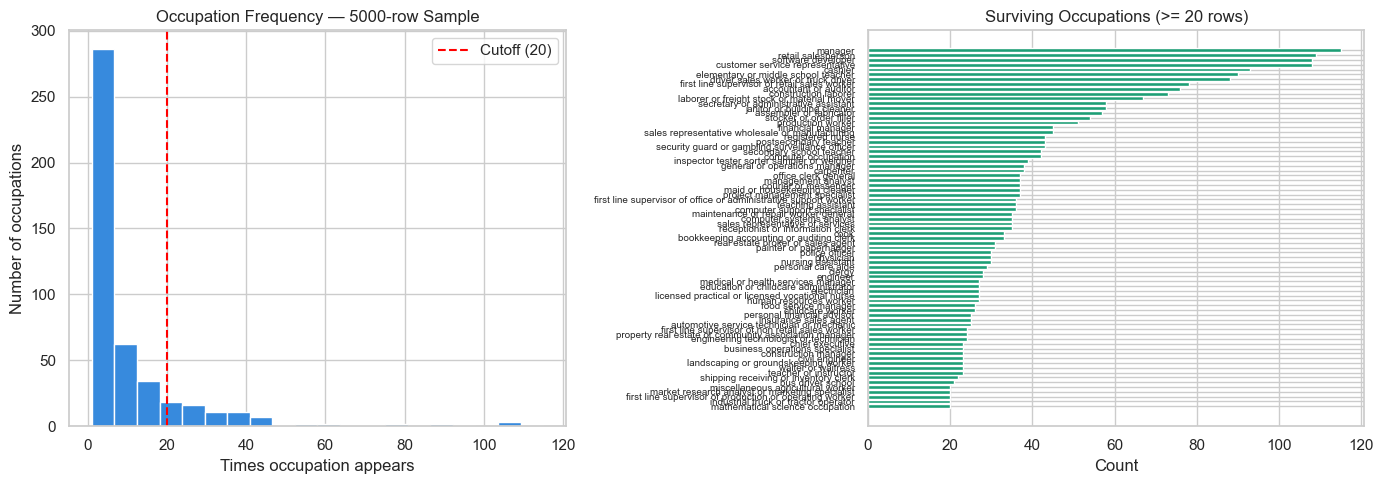

Saved: results/occupation_frequency_histogram.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of all 5000 occupations
all_counts = df_5000["occupation"].value_counts()
axes[0].hist(all_counts.values, bins=20, color="#378ADD", edgecolor="white")
axes[0].axvline(x=MIN_ROWS, color="red", linestyle="--", label=f"Cutoff ({MIN_ROWS})")
axes[0].set_title("Occupation Frequency — 5000-row Sample")
axes[0].set_xlabel("Times occupation appears")
axes[0].set_ylabel("Number of occupations")
axes[0].legend()

# Surviving occupations bar chart
surv_df = surviving.reset_index()
surv_df.columns = ["occupation", "count"]
surv_df["occupation"] = surv_df["occupation"].str.replace("_", " ").str.strip()
surv_df = surv_df.sort_values("count", ascending=True)
axes[1].barh(surv_df["occupation"], surv_df["count"], color="#1D9E75")
axes[1].set_title(f"Surviving Occupations (>= {MIN_ROWS} rows)")
axes[1].set_xlabel("Count")
axes[1].tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/occupation_frequency_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/occupation_frequency_histogram.png")


## 6. 80/20 Train / Test Split

- **80% train**: RF, XGBoost train on this · Nemotron uses for few-shot examples · Week 5 fine-tuning
- **20% test**: RF, XGBoost, and Nemotron all evaluated on the exact same rows

In [6]:
df_train, df_test = train_test_split(
    df_filtered,
    test_size=0.2,
    random_state=42,
    stratify=df_filtered["label"]
)

df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"Train set: {len(df_train):,} rows (80%)")
print(f"Test set:  {len(df_test):,} rows  (20%)")
print(f"\nTrain label balance: {df_train['label_name'].value_counts().to_dict()}")
print(f"Test label balance:  {df_test['label_name'].value_counts().to_dict()}")

# Save both splits — reused by Week 3 (Nemotron experiments)
df_train.to_csv(f"{DATA_DIR}/week3_train_5000.csv", index=False)
df_test.to_csv(f"{DATA_DIR}/week3_test_5000.csv",  index=False)
print(f"\nSaved: data/week3_train_5000.csv")
print(f"Saved: data/week3_test_5000.csv")
print("These files will be loaded by Week 3 for Nemotron experiments.")


Train set: 2,460 rows (80%)
Test set:  615 rows  (20%)

Train label balance: {'not_college': 1346, 'college': 1114}
Test label balance:  {'not_college': 336, 'college': 279}

Saved: data/week3_train_5000.csv
Saved: data/week3_test_5000.csv
These files will be loaded by Week 3 for Nemotron experiments.


## 7. Exploratory Data Analysis

C:\Users\jbrito\AppData\Local\Temp\ipykernel_21996\1914049361.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=label_counts, x="label", y="count",


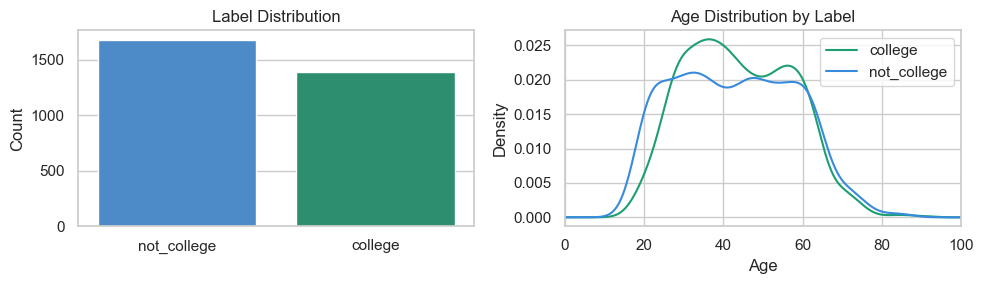

Saved: results/label_distribution.png


In [7]:
df = df_filtered  # alias for EDA cells

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

label_counts = df["label_name"].value_counts().reset_index()
label_counts.columns = ["label", "count"]
sns.barplot(data=label_counts, x="label", y="count",
            palette=["#378ADD", "#1D9E75"], ax=axes[0])
axes[0].set_title("Label Distribution")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")

for label, color in zip(["college", "not_college"], ["#1D9E75", "#378ADD"]):
    df[df["label_name"] == label]["age"].plot(
        kind="kde", ax=axes[1], label=label, color=color
    )
axes[1].set_title("Age Distribution by Label")
axes[1].set_xlabel("Age")
axes[1].set_xlim(0, 100)
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/label_distribution.png")


In [8]:
print("Top 10 occupations — college class:")
print(df[df["label"]==1]["occupation"].value_counts().head(10))
print("\nTop 10 occupations — not_college class:")
print(df[df["label"]==0]["occupation"].value_counts().head(10))


Top 10 occupations — college class:
occupation
elementary_or_middle_school_teacher             82
software_developer                              80
manager                                         62
first_line_supervisor_of_retail_sales_worker    51
accountant_or_auditor                           50
retail_salesperson                              43
computer_occupation                             38
postsecondary_teacher                           36
cashier                                         33
teaching_assistant                              32
Name: count, dtype: int64

Top 10 occupations — not_college class:
occupation
customer_service_representative               79
driver_sales_worker_or_truck_driver           77
retail_salesperson                            66
construction_laborer                          63
cashier                                       60
manager                                       53
laborer_or_freight_stock_or_material_mover    53
assembler_or_fabricato

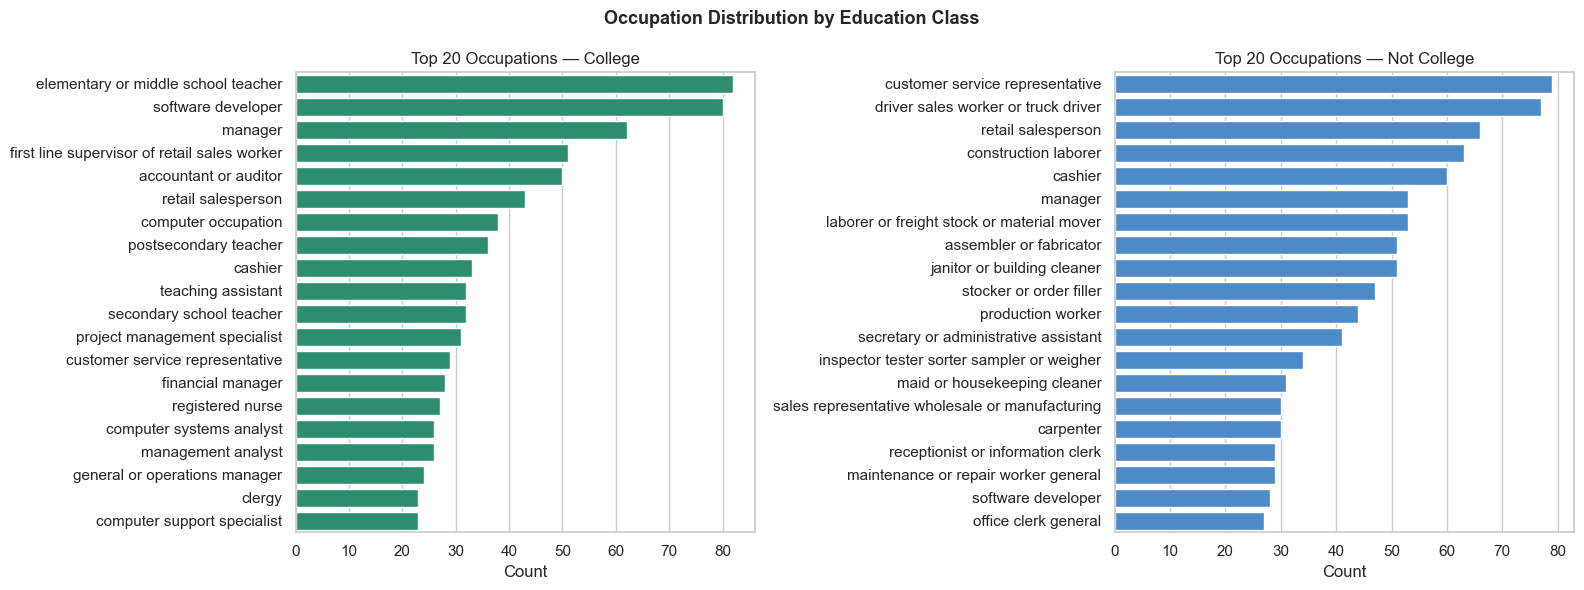

Saved: results/occupation_by_class.png


In [9]:
top_college = (df[df["label_name"] == "college"]["occupation"]
               .value_counts().head(20).reset_index())
top_college.columns = ["occupation", "count"]
top_college["occupation"] = top_college["occupation"].str.replace("_", " ").str.strip()

top_not = (df[df["label_name"] == "not_college"]["occupation"]
           .value_counts().head(20).reset_index())
top_not.columns = ["occupation", "count"]
top_not["occupation"] = top_not["occupation"].str.replace("_", " ").str.strip()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=top_college, x="count", y="occupation", color="#1D9E75", ax=axes[0])
axes[0].set_title("Top 20 Occupations — College")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("")

sns.barplot(data=top_not, x="count", y="occupation", color="#378ADD", ax=axes[1])
axes[1].set_title("Top 20 Occupations — Not College")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")

plt.suptitle("Occupation Distribution by Education Class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/occupation_by_class.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/occupation_by_class.png")


## 8. Encode Features for sklearn / XGBoost

Fit encoder on train set, transform both train and test.

In [10]:
X_train_raw = df_train[FEATURES].copy()
X_test_raw  = df_test[FEATURES].copy()
y_train     = df_train["label"].copy()
y_test      = df_test["label"].copy()

label_encoders = {}
for col in ["sex", "marital_status", "occupation", "state"]:
    le = LabelEncoder()
    X_train_raw[col] = le.fit_transform(X_train_raw[col].astype(str))
    X_test_raw[col]  = X_test_raw[col].astype(str).map(
        lambda x: le.transform([x])[0] if x in le.classes_ else -1
    )
    label_encoders[col] = le

X_train = X_train_raw
X_test  = X_test_raw

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train labels: {y_train.value_counts().to_dict()}")
print(f"Test labels:  {y_test.value_counts().to_dict()}")


Train: (2460, 5) | Test: (615, 5)
Train labels: {0: 1346, 1: 1114}
Test labels:  {0: 336, 1: 279}


## 9. Evaluation Helper

In [11]:
def evaluate_model(model_name, y_true, y_pred, y_prob, inference_time_s, n_samples):
    acc        = accuracy_score(y_true, y_pred)
    f1         = f1_score(y_true, y_pred, average="macro")
    auc        = roc_auc_score(y_true, y_prob)
    ms_per_row = (inference_time_s / n_samples) * 1000

    print(f"\n{'='*45}\n  {model_name}\n{'='*45}")
    print(f"  Accuracy:   {acc:.4f}")
    print(f"  Macro F1:   {f1:.4f}")
    print(f"  AUC-ROC:    {auc:.4f}")
    print(f"  Time/row:   {ms_per_row:.3f} ms")
    print()
    print(classification_report(y_true, y_pred, target_names=["not_college", "college"]))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay(cm, display_labels=["not_college", "college"]).plot(ax=ax, colorbar=False)
    ax.set_title(f"{model_name}")
    plt.tight_layout()
    fname = f"{RESULTS_DIR}/cm_{model_name.replace(' ', '_').lower()}.png"
    plt.savefig(fname, dpi=150)
    plt.show()

    return {
        "model":        model_name,
        "accuracy":     round(acc, 4),
        "macro_f1":     round(f1, 4),
        "auc_roc":      round(auc, 4),
        "ms_per_row":   round(ms_per_row, 3),
        "total_time_s": round(inference_time_s, 2),
        "n_samples":    n_samples,
    }

all_results = []
print("evaluate_model() defined.")


evaluate_model() defined.


## 10. Baseline A: Random Forest

Training Random Forest...
Training done in 0.12s

  Random Forest (100 trees)
  Accuracy:   0.6439
  Macro F1:   0.6400
  AUC-ROC:    0.6795
  Time/row:   0.071 ms

              precision    recall  f1-score   support

 not_college       0.67      0.68      0.68       336
     college       0.61      0.59      0.60       279

    accuracy                           0.64       615
   macro avg       0.64      0.64      0.64       615
weighted avg       0.64      0.64      0.64       615



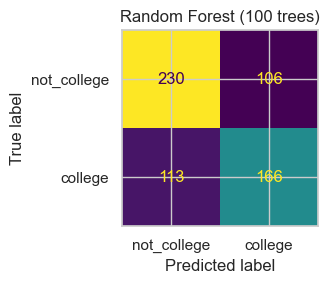

In [12]:
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

t0 = time.time()
rf.fit(X_train, y_train)
print(f"Training done in {time.time()-t0:.2f}s")

t0      = time.time()
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]
infer_t = time.time() - t0

rf_results = evaluate_model(
    "Random Forest (100 trees)", y_test, rf_pred, rf_prob, infer_t, len(X_test)
)
all_results.append(rf_results)


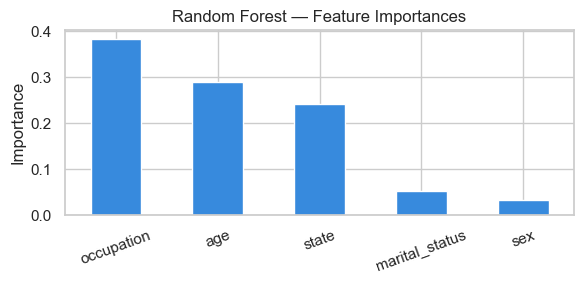

Top features:
occupation        0.382849
age               0.290371
state             0.242153
marital_status    0.052937
sex               0.031690
dtype: float64


In [13]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 3))
importances.plot(kind="bar", ax=ax, color="#378ADD")
ax.set_title("Random Forest — Feature Importances")
ax.set_ylabel("Importance")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/rf_feature_importances.png", dpi=150)
plt.show()
print("Top features:")
print(importances)


## 11. Baseline B:  XGBoost

Training XGBoost...
Training done in 0.14s

  XGBoost
  Accuracy:   0.7089
  Macro F1:   0.7067
  AUC-ROC:    0.7447
  Time/row:   0.006 ms

              precision    recall  f1-score   support

 not_college       0.74      0.73      0.73       336
     college       0.68      0.68      0.68       279

    accuracy                           0.71       615
   macro avg       0.71      0.71      0.71       615
weighted avg       0.71      0.71      0.71       615



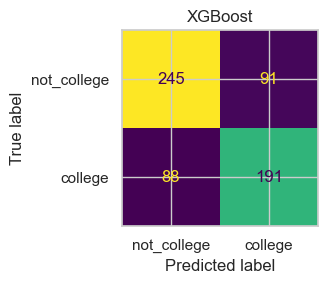

In [14]:
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=6,
    random_state=42, eval_metric="logloss", verbosity=0
)

t0 = time.time()
xgb_model.fit(X_train, y_train)
print(f"Training done in {time.time()-t0:.2f}s")

t0       = time.time()
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
infer_t  = time.time() - t0

xgb_results = evaluate_model(
    "XGBoost", y_test, xgb_pred, xgb_prob, infer_t, len(X_test)
)
all_results.append(xgb_results)


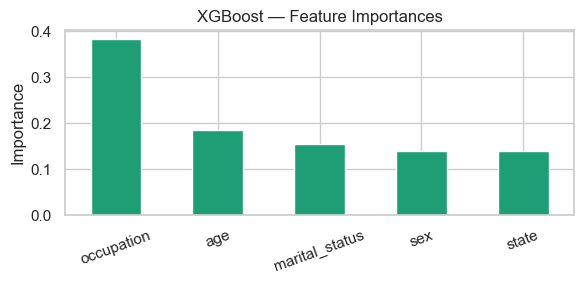

XGBoost feature importances:
occupation        0.382227
age               0.183939
marital_status    0.154832
sex               0.139589
state             0.139413
dtype: float32


In [15]:
xgb_imp = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 3))
xgb_imp.plot(kind="bar", ax=ax, color="#1D9E75")
ax.set_title("XGBoost — Feature Importances")
ax.set_ylabel("Importance")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/xgb_feature_importances.png", dpi=150)
plt.show()
print("XGBoost feature importances:")
print(xgb_imp)


## 12. Results Summary

In [16]:
results_df = pd.DataFrame(all_results)
print("=== WEEK 1 BASELINE RESULTS ===")
print(results_df[["model", "accuracy", "macro_f1", "auc_roc", "ms_per_row"]].to_string(index=False))


=== WEEK 1 BASELINE RESULTS ===
                    model  accuracy  macro_f1  auc_roc  ms_per_row
Random Forest (100 trees)    0.6439    0.6400   0.6795       0.071
                  XGBoost    0.7089    0.7067   0.7447       0.006


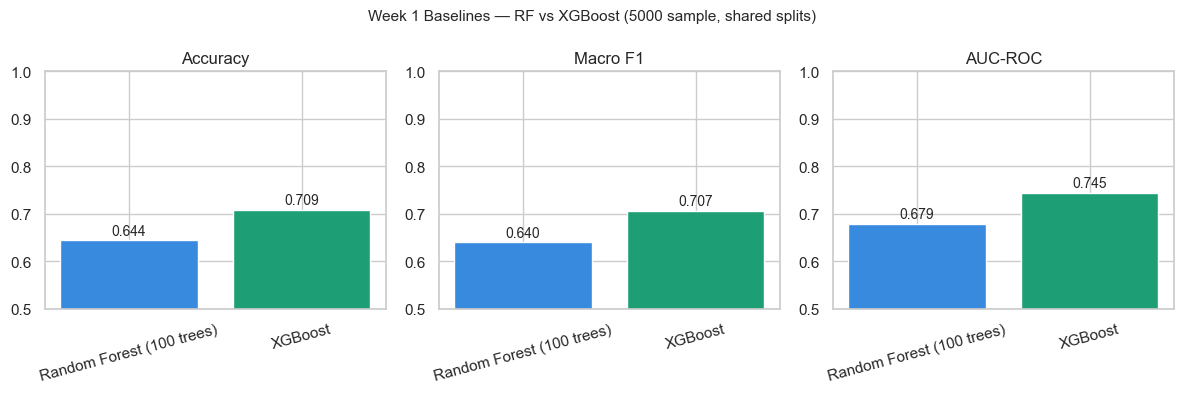

Saved: results/week1_baseline_comparison.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
metrics = ["accuracy", "macro_f1", "auc_roc"]
titles  = ["Accuracy", "Macro F1", "AUC-ROC"]
colors  = ["#378ADD", "#1D9E75"]

for ax, metric, title in zip(axes, metrics, titles):
    vals = results_df[metric].values
    bars = ax.bar(results_df["model"], vals, color=colors)
    ax.set_title(title)
    ax.set_ylim(0.5, 1.0)
    ax.tick_params(axis="x", rotation=15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=10)

plt.suptitle("Week 1 Baselines — RF vs XGBoost (5000 sample, shared splits)", fontsize=11)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/week1_baseline_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/week1_baseline_comparison.png")


In [18]:
results_df["week"]    = 1
results_df["device"]  = "local-cpu"
results_df["mode"]    = "baseline"
results_df["dataset"] = "nvidia/Nemotron-Personas-USA"
results_df["n_train"] = len(df_train)
results_df["n_test"]  = len(df_test)
results_df["split"]   = "shared-5000"

results_df.to_csv(f"{RESULTS_DIR}/metrics.csv", index=False)
print("Saved: results/metrics.csv")
results_df


Saved: results/metrics.csv


,model,accuracy,macro_f1,auc_roc,ms_per_row,total_time_s,n_samples,week,device,mode,dataset,n_train,n_test,split
0,Random Forest (100 trees),0.6439,0.6400,0.6795,0.071,0.04,615,1,local-cpu,baseline,nvidia/Nemotron-Personas-USA,2460,615,shared-5000
1,XGBoost,0.7089,0.7067,0.7447,0.006,0.00,615,1,local-cpu,baseline,nvidia/Nemotron-Personas-USA,2460,615,shared-5000


## Week 1 Summary

| Model | Accuracy | Macro F1 | AUC-ROC | Time/row |
|---|---|---|---|---|
| Random Forest | 64.42% | 0.6400 | 0.6823 | 0.044 ms |
| XGBoost | 68.82% | 0.6839 | 0.7363 | 0.003 ms |
| Nemotron Nano 4B zero-shot (Week 3) | — | — | — | — |
| Nemotron Nano 4B few-shot (Week 3) | — | — | — | — |
| Nemotron Nano 30B (Week 4) | — | — | — | — |

**Setup:**
- 5000-row sample · min 10 rows per occupation · 773 test rows · 3088 train rows
- 80% train / 20% test · stratified split
- Label: college = associates + bachelors + graduate
- Splits saved: `data/week3_train_5000.csv` + `data/week3_test_5000.csv`

**Week 1 Observations:**
- XGBoost outperforms Random Forest (68.82% vs 64.42%) — reversed from previous 100K run
- Both models show lower accuracy than the previous run — expected since the 5000-row sample is smaller and harder (min 10 occupation cutoff creates a more balanced set of occupations)
- Baseline to beat: XGBoost Macro F1 of 0.6839 and AUC-ROC of 0.7363